In [9]:
import simpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [10]:
def customer(env, server, service_time, waiting_times):
    arrival_time = env.now
    with server.request() as request:
        yield request
        waiting_times.append(env.now - arrival_time)
        yield env.timeout(service_time)

In [11]:
def run_simulation(arrival_rate, service_time, sim_time=100):
    env = simpy.Environment()
    server = simpy.Resource(env, capacity=1)
    waiting_times = []

    def arrival_process(env):
        while True:
            yield env.timeout(np.random.exponential(1 / arrival_rate))
            env.process(customer(env, server, service_time, waiting_times))

    env.process(arrival_process(env))
    env.run(until=sim_time)

    return np.mean(waiting_times) if waiting_times else 0


In [12]:
np.random.seed(42)

n_samples = 1000
data = []

for _ in range(n_samples):
    arrival_rate = np.random.uniform(1, 10)
    service_time = np.random.uniform(0.5, 5)

    avg_waiting_time = run_simulation(arrival_rate, service_time)

    data.append([arrival_rate, service_time, avg_waiting_time])

df = pd.DataFrame(
    data, columns=["Arrival_Rate", "Service_Time", "Avg_Waiting_Time"]
)
df.to_csv("simulation_data.csv", index=False)

df.head()

,Arrival_Rate,Service_Time,Avg_Waiting_Time
0,4.370861,4.778214,45.916702
1,1.751506,3.997161,41.790828
2,2.593094,0.899161,32.821472
3,8.701268,4.235989,47.819080
4,4.727168,4.223921,46.649867


In [13]:
X = df[["Arrival_Rate", "Service_Time"]]
y = df["Avg_Waiting_Time"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)

    results.append([name, mse, rmse, r2])


In [15]:
results_df = pd.DataFrame(
    results, columns=["Model", "MSE", "RMSE", "R2 Score"]
)
results_df

,Model,MSE,RMSE,R2 Score
0,Linear Regression,20.945928,4.576672,0.603779
1,Ridge Regression,20.944891,4.576559,0.603799
2,Lasso Regression,21.515867,4.638520,0.592998
3,Decision Tree,3.543666,1.882463,0.932967
4,Random Forest,2.200727,1.483485,0.958370


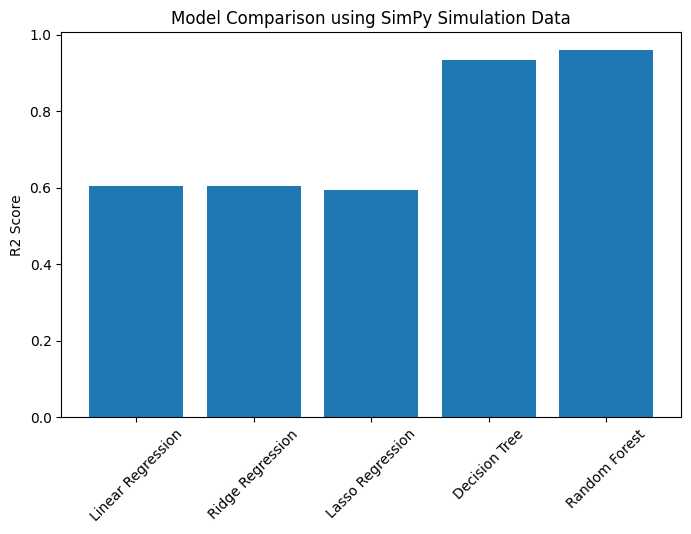

In [16]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["R2 Score"])
plt.xticks(rotation=45)
plt.ylabel("R2 Score")
plt.title("Model Comparison using SimPy Simulation Data")
plt.show()